Используйте базу акций Лукойла.

Сделайте несколько усовершенствований в предсказании временного ряда.
Добавьте к исходному сигналу расширенные данные:

* попарные разности каналов
* модули попарных разностей каналов
* попарные произведения каналов
* обратное значение каналов x_new = 1/(x + 1e-3)
* первые производные каналов (x[n] - x[n-1])
* вторые производные каналов (x[n] - 2*x[n-1] + x[n-2])

Примените абсолютно новый подход. Сделайте бОльший “просмотр сети в прошлое”, при формировании входного сигнала используйте:

* 100 точек с шагом назад по 1,

* 100 точек с шагом назад по 10 (или сами точки, или среднее по отрезку в 10 точек).
* Объедините эти точки

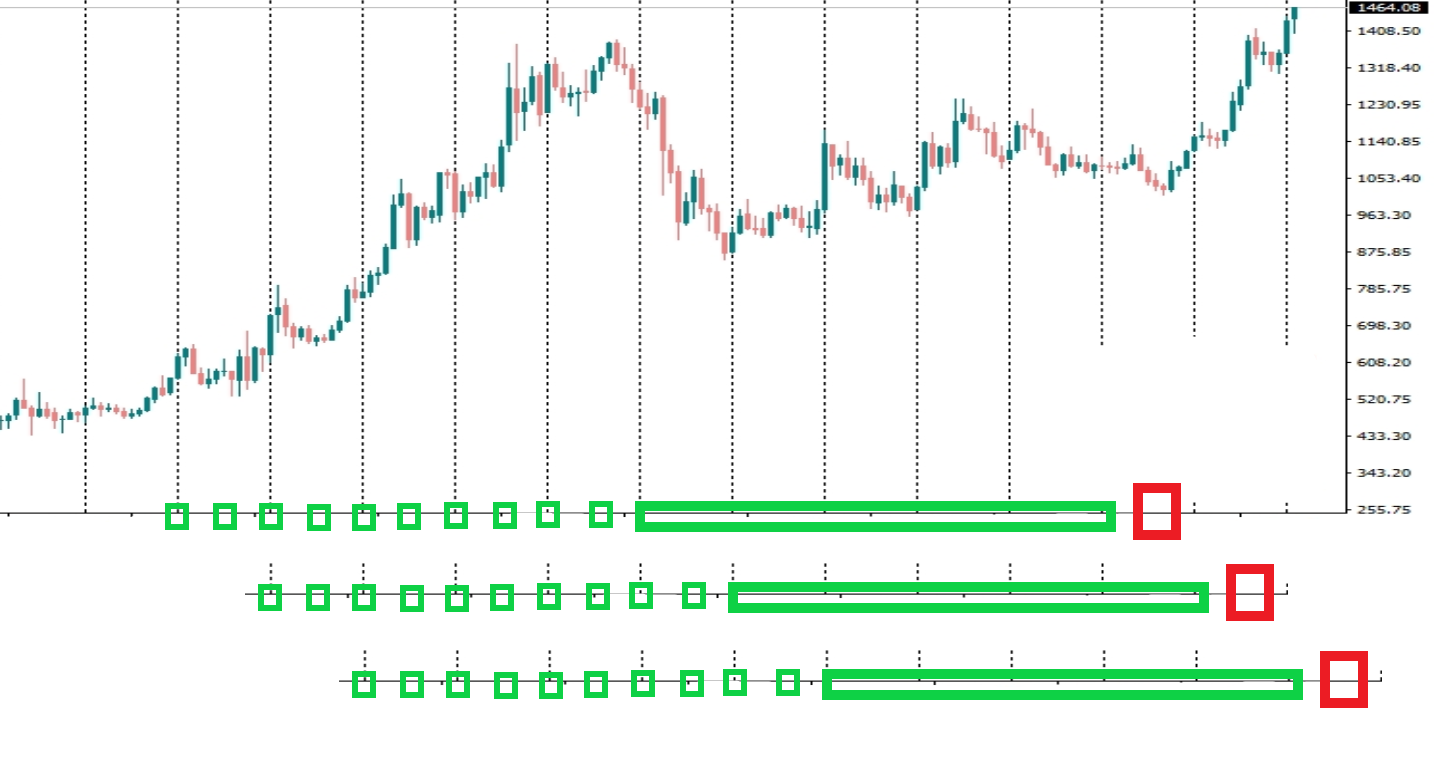

## Подготовка

In [ ]:
import psutil

ram = psutil.virtual_memory()

print(f"Всего RAM: {ram.total / 1024**3:.2f} GB")
print(f"Свободно: {ram.available / 1024**3:.2f} GB")

Всего RAM: 12.67 GB
Свободно: 11.53 GB


In [ ]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Классы-конструкторы моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, LSTM, MaxPooling1D

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировщики
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Коллбэк
from tensorflow.keras.callbacks import LearningRateScheduler

# Загрузка датасетов из облака google
import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt

# Отрисовка графики в ячейке colab
%matplotlib inline

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Назначение размера и стиля графиков по умолчанию

from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

In [ ]:
# Загрузка датасетов из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/16_17.csv', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/18_19.csv', None, quiet=True)

'18_19.csv'

In [ ]:
# Чтение данных в таблицы с удалением ненужных столбцов

data16_17 = pd.read_csv('16_17.csv', sep=';').drop(columns=['DATE', 'TIME'])
data18_19 = pd.read_csv('18_19.csv', sep=';').drop(columns=['DATE', 'TIME'])

In [ ]:
# Просмотр размерностей получившихся таблиц

print(data16_17.shape)
print(data18_19.shape)

(263925, 5)
(217947, 5)


In [ ]:
# Создание общего набора данных из двух датасетов

data = pd.concat([data16_17,data18_19])   # Объединение датасетов
data = data.reset_index(drop = True)      # Обнуление индексов

# Проверка формы данных
print(data.shape)

(481872, 5)


In [ ]:
# Получение названий столбцов

col = data.columns
print(col)

Index(['OPEN', 'MAX', 'MIN', 'CLOSE', 'VOLUME'], dtype='object')


In [ ]:
# Задание циклов для столбцов таким образом, чтобы происходил перебор всех возможных пар:
# Перебор индексов массива с именами столбцов 'OPEN', 'MAX', 'MIN', 'CLOSE', 'VOLUME',
# получая пары 'OPEN' и 'MAX', 'OPEN' и 'MIN', 'OPEN' и 'CLOSE' ..., 'MAX' и 'MIN', 'MAX' и 'CLOSE' и т.д

for i in range(col.shape[0]): # Для всех пар
    for j in range(i + 1 , col.shape[0]): # Расчет
        data[col[i] + '-' + col[j]] = data[col[i]] - data[col[j]] # Разности
        data['|' + col[i] + '-' + col[j] + '|'] = abs(data[col[i]] - data[col[j]]) # Модулей разностей
        #data[col[i] + '*' + col[j]] = data[col[i]] * data[col[j]] # Произведения

# Для каждого столбца 'OPEN', 'MAX', 'MIN', 'CLOSE', 'VOLUME' расчет:
for i in col:
    # Обратные значения. 1e-3 в формуле нужно, чтобы случайно не разделить на 0
    data['Обратный ' + i] = 1 / (data[i] + 1e-3)
    # Создание пустого столбца
    data['Производная от ' + i] = np.nan
    # При помощи срезов расчет первых производных, .reset_index(drop=True) нужен для корректных расчетов
    data['Производная от ' + i][1:] = data[i][1:].reset_index(drop=True) - data[i][:-1].reset_index(drop=True)
    # Создание пустого столбца
    data['Вторая производная от ' + i] = np.nan
    # При помощи срезов расчет вторых производных
    data['Вторая производная от ' + i][2:] = data[i][2:].reset_index(drop=True) - 2 * data[i][1:-1].reset_index(drop=True) + data[i][:-2].reset_index(drop=True)


In [ ]:
# Просмотр результатов
data

,OPEN,MAX,MIN,CLOSE,VOLUME,OPEN-MAX,|OPEN-MAX|,OPEN-MIN,|OPEN-MIN|,OPEN-CLOSE,...,Вторая производная от MAX,Обратный MIN,Производная от MIN,Вторая производная от MIN,Обратный CLOSE,Производная от CLOSE,Вторая производная от CLOSE,Обратный VOLUME,Производная от VOLUME,Вторая производная от VOLUME
0,2351.0,2355.8,2350.0,2350.0,2547,-4.8,4.8,1.0,1.0,1.0,...,NaN,0.000426,NaN,NaN,0.000426,NaN,NaN,0.000393,NaN,NaN
1,2352.9,2355.7,2350.0,2355.7,195,-2.8,2.8,2.9,2.9,-2.8,...,NaN,0.000426,0.0,NaN,0.000425,5.7,NaN,0.005128,-2352.0,NaN
2,2355.6,2356.0,2351.4,2354.1,257,-0.4,0.4,4.2,4.2,1.5,...,0.4,0.000425,1.4,1.4,0.000425,-1.6,-7.3,0.003891,62.0,2414.0
3,2354.5,2355.0,2351.2,2353.7,763,-0.5,0.5,3.3,3.3,0.8,...,-1.3,0.000425,-0.2,-1.6,0.000425,-0.4,1.2,0.001311,506.0,444.0
4,2353.1,2353.9,2353.1,2353.6,231,-0.8,0.8,0.0,0.0,-0.5,...,-0.1,0.000425,1.9,2.1,0.000425,-0.1,0.3,0.004329,-532.0,-1038.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481867,5183.5,5183.5,5183.5,5183.5,31523,0.0,0.0,0.0,0.0,0.0,...,11.5,0.000193,16.0,18.0,0.000193,11.5,10.0,0.000032,29174.0,29480.0
481868,5183.5,5183.5,5183.5,5183.5,5090,0.0,0.0,0.0,0.0,0.0,...,-11.5,0.000193,0.0,-16.0,0.000193,0.0,-11.5,0.000196,-26433.0,-55607.0
481869,5183.5,5183.5,5183.5,5183.5,230,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000193,0.0,0.0,0.000193,0.0,0.0,0.004348,-4860.0,21573.0
481870,5183.5,5183.5,5183.5,5183.5,5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000193,0.0,0.0,0.000193,0.0,0.0,0.199960,-225.0,4635.0


In [ ]:
# Использование всех столбцов, кроме первых двух
data = np.array(data.iloc[2:])

# Перевод в numpy
data = np.array(data)

# Переменная, для использования одной и той же архитектуры под разные матрицы
columnsamount = data.shape[1]

In [ ]:
# длина "короткого" контекста (последние наблюдения)
SEQ_SHORT = 20
# длина "длинного" контекста (разреженная история)
SEQ_LONG = 20
LONG_STEP = 10

TEST_LEN = 8000
BATCH_SIZE = 8
TRAIN_LEN = len(data) - TEST_LEN

# Close находится в 4 колонке исходных данных
TARGET_INDEX = 3

# train/test
data_train = data[:TRAIN_LEN]
data_test = data[TRAIN_LEN:]

# нормализация
x_scaler = MinMaxScaler()
x_train_scaled = x_scaler.fit_transform(data_train)
x_test_scaled = x_scaler.transform(data_test)

y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(
    data_train[:, TARGET_INDEX].reshape(-1,1)
)

y_test_scaled = y_scaler.transform(
    data_test[:, TARGET_INDEX].reshape(-1,1)
)

print(x_train_scaled.shape)
print(x_test_scaled.shape)

(473870, 40)
(8000, 40)


Функция формирования датасета

In [ ]:
def make_dataset(x, y,
                 seq_short=20,
                 seq_long=20,
                 long_step=10):
    # стартовый индекс (чтобы хватило истории для длинного окна)
    start_index = seq_long * long_step
    # количество обучающих примеров
    n_samples = len(x) - start_index - 1
    # итоговая длина входного вектора:
    # короткая + длинная истори
    total_steps = seq_short + seq_long
    n_features = x.shape[1]

    # массив входов (X)
    X = np.zeros(
        (n_samples, total_steps, n_features),
        dtype=np.float32
    )
    # массив таргетов (Y)
    Y = np.zeros(
        (n_samples, 1),
        dtype=np.float32
    )
    # формирование выборки скользящим окном
    for idx, i in enumerate(
        range(start_index, len(x)-1)
    ):

        # последние 20 шагов подряд
        short_part = x[
            i-seq_short:i
        ]

        # разреженные точки назад с шагом LONG_STEP
        long_indices = np.arange(
            i-seq_long*long_step,
            i,
            long_step
        )

        long_part = x[long_indices]

        # объединение двух типов контекста
        X[idx] = np.concatenate(
            [short_part, long_part],
            axis=0
        )

        Y[idx] = y[i]

          # лог прогресса
        if idx % 50000 == 0:
            print(idx)

    return X, Y

# создание train/test
x_train, y_train = make_dataset(
    x_train_scaled,
    y_train_scaled
)

x_test, y_test = make_dataset(
    x_test_scaled,
    y_test_scaled
)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

0
50000
100000
150000
200000
250000
300000
350000
400000
450000
0
(473669, 40, 40)
(473669, 1)
(7799, 40, 40)
(7799, 1)


LSTM сеть

In [ ]:
model = Sequential([

    LSTM(
        64,
        input_shape=(
            x_train.shape[1],
            x_train.shape[2]
        )
    ),

    Dense(32, activation='relu'),

    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)



Обучение

In [ ]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/5
59209/59209 ━━━━━━━━━━━━━━━━━━━━ 377s 6ms/step - loss: 3.3174e-05 - mae: 0.0025 - val_loss: 3.1824e-06 - val_mae: 0.0012
Epoch 2/5
59209/59209 ━━━━━━━━━━━━━━━━━━━━ 371s 6ms/step - loss: 3.0244e-06 - mae: 0.0013 - val_loss: 6.2434e-06 - val_mae: 0.0022
Epoch 3/5
59209/59209 ━━━━━━━━━━━━━━━━━━━━ 367s 6ms/step - loss: 2.2126e-06 - mae: 0.0011 - val_loss: 3.3546e-06 - val_mae: 0.0015
Epoch 4/5
59209/59209 ━━━━━━━━━━━━━━━━━━━━ 365s 6ms/step - loss: 1.7959e-06 - mae: 0.0010 - val_loss: 1.7424e-06 - val_mae: 9.4677e-04
Epoch 5/5
59209/59209 ━━━━━━━━━━━━━━━━━━━━ 365s 6ms/step - loss: 1.5451e-06 - mae: 9.2309e-04 - val_loss: 1.6068e-06 - val_mae: 9.1860e-04


In [ ]:
pred = model.predict(x_test)

pred_real = y_scaler.inverse_transform(pred)

y_test_real = y_scaler.inverse_transform(y_test)

244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Визуализациия

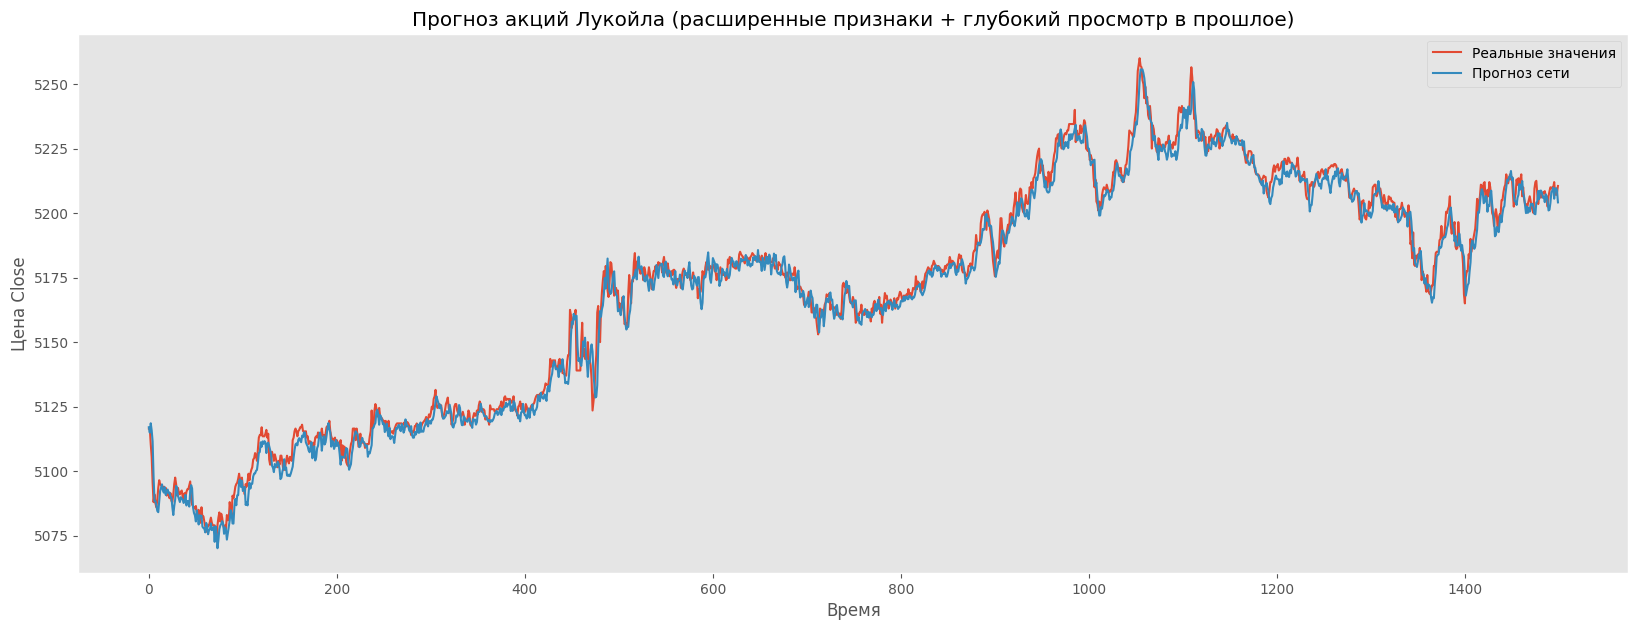

In [ ]:

plt.figure(figsize=(20,7))

plt.plot(
    y_test_real[:1500],
    label='Реальные значения'
)

plt.plot(
    pred_real[:1500],
    label='Прогноз сети'
)

plt.title(
    'Прогноз акций Лукойла '
    '(расширенные признаки + глубокий просмотр в прошлое)'
)

plt.xlabel('Время')
plt.ylabel('Цена Close')
plt.legend()
plt.grid()

plt.show()